In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
print("Does file exist?", os.path.exists("pasta2.jpg"))
print("Files in current directory:", os.listdir())

Does file exist? False
Files in current directory: ['.config', 'sample_data']


In [ ]:
!pip install -q google-genai

In [ ]:
from pyngrok import ngrok

# Kill all active ngrok tunnels and processes
ngrok.kill()
print("All ngrok processes terminated.")

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
#This is to support Streamlit and provide a link to  NgrokTunnel: "https://crushed-starboard-sprawl.ngrok-free.dev" -> "http://localhost:8501"

import os
import subprocess
from google.colab import userdata
from pyngrok import ngrok, conf

# 1. Kill any existing Streamlit and ngrok processes
!pkill -f streamlit
!pkill -f ngrok


# 2. Retrieve OpenAI API key from Colab Secrets and pass it as an environment variable
# this was added just for OPENAPI
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

# 2. Retrieve ngrok auth token from Colab Secrets
NGROK_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(NGROK_TOKEN)

# 3. Start Streamlit in the background
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
# Start a fresh tunnel without a custom domain
public_url = ngrok.connect(8501)
print(f"\n Your Streamlit App is live at: {public_url}")


 Your Streamlit App is live at: NgrokTunnel: "https://crushed-starboard-sprawl.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os
import base64
from openai import OpenAI
from google import genai
from google.genai import types

# --- 1. Page Configuration ---
st.set_page_config(
    page_title="Food-11 Classifier",
    page_icon="🍲",
    layout="centered"
)
st.title("🍲 Food-11 Classifier App")
st.write("Upload an image of food to classify it using your trained CNN model or compare it with GPT-4o and Gemini.")

# --- 2. Re-instantiate Architecture ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=11, p=0.5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.dropout = nn.Dropout(p=p)

        # Global pooling layer
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- 3. Cached Model Loader ---
@st.cache_resource
def load_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_names = ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food',
                   'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
    model = SimpleCNN(num_classes=len(class_names), p=0.5)
    if os.path.exists("food11_simple_cnn.pth"):
        model.load_state_dict(torch.load("food11_simple_cnn.pth", map_location=device))
    model.to(device)
    model.eval()
    return model, class_names, device

model, class_names, device = load_model()

# --- 4. OpenAI Classification Function ---
def classify_image_with_gpt(image_bytes, class_names):
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        return "Error: OPENAI_API_KEY environment variable is not set."

    try:
        client = OpenAI(api_key=api_key)
        base64_image = base64.b64encode(image_bytes).decode('utf-8')
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": f"Classify this food image into exactly one of these 11 categories: {class_names}. Return just the category name."
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{base64_image}"
                            }
                        }
                    ]
                }
            ],
            max_tokens=30
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)}"

# --- 5. Gemini Classification Function ---
def classify_image_with_gemini(image, class_names):
    try:
        client = genai.Client()
        prompt = f"Classify this food image into exactly one of these 11 categories: {class_names}. Return just the category name."

        response = client.models.generate_content(
            model='gemini-3.5-flash',
            contents=[image, prompt]
        )
        return response.text.strip()
    except Exception as e:
        return f"Error: {str(e)}"

# --- 6. Image Preprocessing Pipeline ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 7. Sidebar / Metrics Section ---
st.sidebar.header("📊 Model Metrics & Info")
st.sidebar.markdown(f"**Architecture:** SimpleCNN")
st.sidebar.markdown(f"**Total Classes:** {len(class_names)}")
st.sidebar.markdown(f"**Device:** {device}")

# --- 8. File Uploader & Prediction ---
uploaded_file = st.file_uploader("Choose a food image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    uploaded_file.seek(0)
    image_bytes = uploaded_file.read()

    col_left, col_right = st.columns([1, 1])

    with col_left:
        st.subheader("Uploaded Image")
        st.image(image, use_container_width=True)

        st.write("---")
        st.subheader("Cloud AI Comparison")

        # GPT-4o Button & Output
        if st.button("🤖 Classify with GPT-4o"):
            with st.spinner("Querying GPT-4o..."):
               gpt_prediction = classify_image_with_gpt(image_bytes, class_names)
               st.info(f"**GPT-4o Prediction:** {gpt_prediction}")

        # Gemini Button & Output
        if st.button("✨ Classify with Gemini"):
            with st.spinner("Querying Gemini..."):
                gemini_prediction = classify_image_with_gemini(image, class_names)
                st.info(f"**Gemini Prediction:** {gemini_prediction}")

    with col_right:
        st.subheader("Prediction Results")
        with st.spinner("Classifying with SimpleCNN..."):
            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(input_tensor)
                probabilities = F.softmax(outputs, dim=1)[0]
                conf, pred_idx = torch.max(probabilities, 0)

            predicted_class = class_names[pred_idx.item()]
            confidence_score = conf.item() * 100

            st.success(f"**CNN Prediction:** {predicted_class}")
            st.metric(label="CNN Confidence Score", value=f"{confidence_score:.2f}%")

        st.write("---")
        st.write("**CNN Class Probabilities:**")
        for i, name in enumerate(class_names):
            prob = probabilities[i].item()
            st.progress(prob, text=f"{name}: {prob*100:.1f}%")

Writing app.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

###Google Gemini

### Download Dataset from Kaggle

To download the dataset directly from Kaggle, you'll need a Kaggle API key. Follow these steps:

1.  Go to your Kaggle account settings ([https://www.kaggle.com/me/account](https://www.kaggle.com/me/account)).
2.  Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
3.  Upload the `kaggle.json` file to your Colab environment in the next code cell. The file should be placed in the `/root/.kaggle/` directory.

In [ ]:
# Install the Kaggle API client
!pip install kaggle

In [ ]:
import os

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# This cell will prompt you to upload your kaggle.json file
# After uploading, it moves the file to the correct location and sets permissions.
from google.colab import files

print("Please upload your 'kaggle.json' file:")
files.upload()

# Move kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured.")

Please upload your 'kaggle.json' file:


Saving kaggle1.json to kaggle1.json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key uploaded and configured.


#Download the dataset

In [ ]:
# Download the dataset
# The dataset ID comes from the URL: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset
!kaggle datasets download trolukovich/food11-image-dataset

print('Dataset download initiated. Please wait for it to complete.')

Dataset URL: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset
License(s): CC0-1.0
100% 1.08G/1.08G [00:14<00:00, 78.9MB/s]

Dataset download initiated. Please wait for it to complete.


#Unzip the Images

In [ ]:
# Unzip the downloaded dataset
# Assuming the downloaded file is named 'food11-image-dataset.zip'
# And unzips into a folder named 'food11' inside /content

import zipfile
import os

zip_path = '/content/food11-image-dataset.zip'
extraction_path = '/content/food11'

if os.path.exists(zip_path):
    os.makedirs(extraction_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'Dataset unzipped successfully to {extraction_path}')

    # Define the root_dir for ImageFolder
    root_dir = extraction_path
    print(f"Setting root directory to: {root_dir}")
else:
    print(f"Error: Zip file not found at {zip_path}")
    root_dir = '/content' # Fallback, though likely to cause issues if dataset not present

Dataset unzipped successfully to /content/food11
Setting root directory to: /content/food11


#Resize, convert images to tensors, and normalise

In [ ]:
#Final
from torchvision import datasets, transforms
import torchvision.transforms as T
import os

# Using standard ImageNet mean and std for normalization
normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])

transform = T.Compose([T.Resize((224, 224)),
                       T.ToTensor(),
                       normalize])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Load the training dataset
try:
    train_data = datasets.ImageFolder(root=os.path.join(root_dir, 'training'), transform=train_transform)
    print('--- Training Data ---')
    print(f"Classes: {train_data.classes}")
    print(f"Class to Index: {train_data.class_to_idx}")
except Exception as e:
    print(f"Error loading training data: {e}")
    print(f"Attempted path: {os.path.join(root_dir, 'training')}")

# Load the validation dataset
try:
    eval_data = datasets.ImageFolder(root=os.path.join(root_dir, 'validation'), transform=transform)
    print('\n--- Validation Data ---')
    print(f"Classes: {eval_data.classes}")
    print(f"Class to Index: {eval_data.class_to_idx}")
except Exception as e:
    print(f"Error loading validation data: {e}")
    print(f"Attempted path: {os.path.join(root_dir, 'validation')}")

# Load the testing dataset (correcting path to 'evaluation')
try:
    test_data = datasets.ImageFolder(root=os.path.join(root_dir, 'evaluation'), transform=transform)
    print('\n--- Testing Data ---')
    print(f"Classes: {test_data.classes}")
    print(f"Class to Index: {test_data.class_to_idx}")
except Exception as e:
    print(f"Error loading testing data: {e}")
    print(f"Attempted path: {os.path.join(root_dir, 'evaluation')}")

--- Training Data ---
Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Class to Index: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}

--- Validation Data ---
Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Class to Index: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}

--- Testing Data ---
Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Class to Index: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 

#ONLY FOR SUBSET!

Run this only to speed up testing.  It takes 50 (or a number of your choosing) from each class, rather than using the entire dataset.

In [ ]:
import torch
from torch.utils.data import Subset, DataLoader
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)

samples_per_class = 50
class_indices = {i: [] for i in range(len(train_data.classes))}

# Group dataset indices by their class label
for idx, (_, label) in enumerate(train_data.samples):
    class_indices[label].append(idx)

# Randomly select 100 indices for each class
selected_indices = []
for label, indices in class_indices.items():
    # If a class has fewer than 100 samples, take all of them
    n_samples = min(samples_per_class, len(indices))
    chosen = np.random.choice(indices, size=n_samples, replace=False)
    selected_indices.extend(chosen)

# Create a new trimmed training dataset using Subset
train_data_subset = Subset(train_data, selected_indices)

# Recreate train_loader with the subset
train_loader = DataLoader(train_data_subset, batch_size=64, shuffle=True)

print(f"Original training dataset size: {len(train_data)}")
print(f"Reduced training dataset size: {len(train_data_subset)} ({samples_per_class} samples max per class)")

Original training dataset size: 9866
Reduced training dataset size: 550 (50 samples max per class)


###print out the labels to validate data

In [ ]:
train_class_to_idx = train_data.class_to_idx
val_class_to_idx = eval_data.class_to_idx
test_class_to_idx = test_data.class_to_idx

print("Train Class to Index mapping:", train_class_to_idx)
print("Validation Class to Index mapping:", val_class_to_idx)
print("Test Class to Index mapping:", test_class_to_idx)

Train Class to Index mapping: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}
Validation Class to Index mapping: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}
Test Class to Index mapping: {'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


#Create Dataloaders

###Entire Dataset!

In [ ]:
import torch
from torch.utils.data import DataLoader

# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_data,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(eval_data,
                        batch_size=batch_size,
                        shuffle=False)
test_loader = DataLoader(test_data,
                         batch_size=batch_size,
                         shuffle=False)

print(f"Training DataLoader has {len(train_loader)} batches of size {batch_size}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {batch_size}")
print(f"Testing DataLoader has {len(test_loader)} batches of size {batch_size}")

Training DataLoader has 155 batches of size 64
Validation DataLoader has 54 batches of size 64
Testing DataLoader has 53 batches of size 64


##Only for SubSet

In [ ]:
import torch
from torch.utils.data import DataLoader

# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_data_subset,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(eval_data,
                        batch_size=batch_size,
                        shuffle=False)
test_loader = DataLoader(test_data,
                         batch_size=batch_size,
                         shuffle=False)

print(f"Training DataLoader has {len(train_loader)} batches of size {batch_size}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {batch_size}")
print(f"Testing DataLoader has {len(test_loader)} batches of size {batch_size}")

Training DataLoader has 9 batches of size 64
Validation DataLoader has 54 batches of size 64
Testing DataLoader has 53 batches of size 64


### Visualize Sample Images
Visualize a few images from the training set to check the data and labels

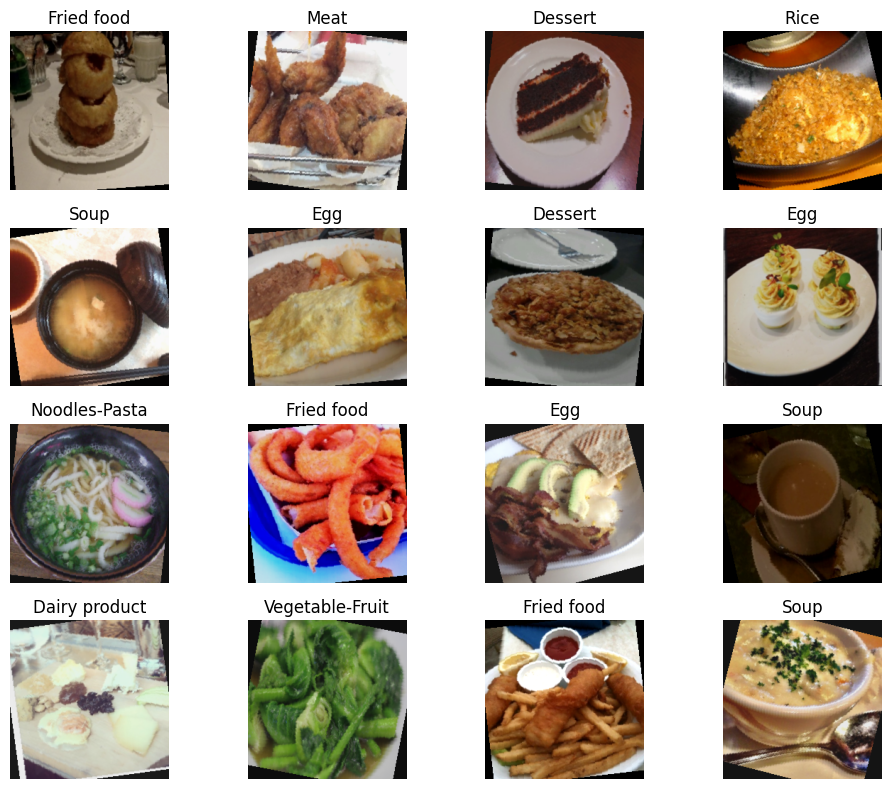

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to unnormalize and display image
def imshow(ax, img, title=None):
    # Unnormalize the image
    # ImageNet mean and std used for normalization in the transform
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean # reverse normalization

    # Clip values to [0, 1] for proper display
    img = torch.clamp(img, 0, 1)

    npimg = img.numpy()

    # Debugging: Print statistics for each image, iterating over channels (first dimension)
    # The numpy array is (C, H, W) before transpose

    ax.imshow(np.transpose(npimg, (1, 2, 0))) # Transpose dimensions for matplotlib (channels last)
    if title is not None:
        ax.set_title(title)
    ax.axis('off') # Hide axes ticks

# Get a batch of training images and labels
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Get class names from the train_data object
class_names = train_data.classes

# Create a figure and a set of subplots
fig, axes = plt.subplots(figsize=(10, 8), nrows=4, ncols=4, sharex=True, sharey=True)
axes = axes.flatten()

# Display 16 images from the batch
for idx in np.arange(16):
    ax = axes[idx]
    imshow(ax, images[idx], title=class_names[labels[idx]])

plt.tight_layout()
plt.show()

/tmp/ipykernel_2398/70908258.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Blues_d')


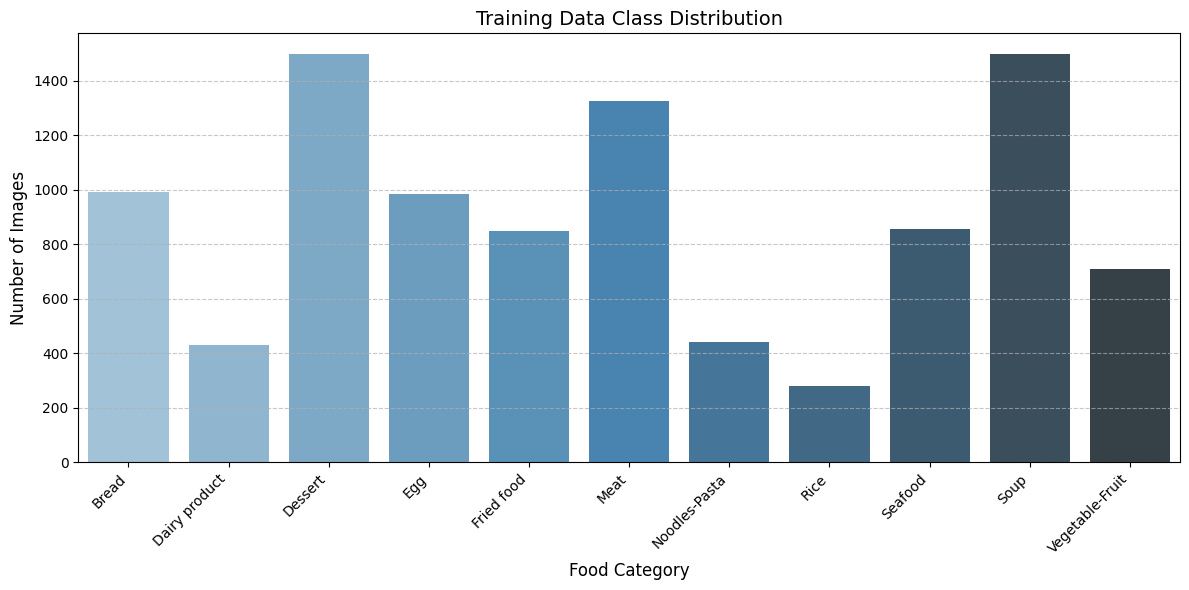

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each class using the dataset's native samples list
targets = [label for _, label in train_data.samples]
counts = {class_name: targets.count(idx) for class_name, idx in train_data.class_to_idx.items()}

# Plotting the class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Blues_d')
plt.title('Training Data Class Distribution', fontsize=14)
plt.xlabel('Food Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

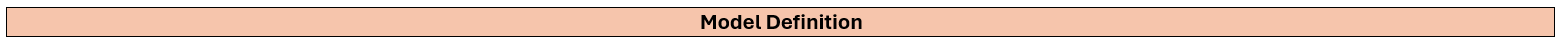
### CNN Model
Now, let's create a basic Convolutional Neural Network (CNN) architecture.

In [ ]:
#A SimpleCNN
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
import torch.nn as nn
import torch.nn.functional as F
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=11):
        super(SimpleCNN, self).__init__()

        # One convolutional layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,
                               kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 112 * 112, num_classes)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 32 * 112 * 112)
        x = self.fc(x)
        return x

# Instantiate the model
num_classes = len(train_data.classes) # Should be 11 for food-11 dataset
model = SimpleCNN(num_classes=num_classes)

print(model)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model moved to {device}")



SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=401408, out_features=11, bias=True)
)
Model moved to cpu


This is an earlier version of the model during testing

In [ ]:
#B
import torch
import torch.optim as optim

# Extract labels from the training subset
targets = [train_data[idx][1] for idx in train_data_subset.indices]
class_counts = [targets.count(i) for i in range(len(train_data.classes))]

# Compute the inverse frequency weights
# Base inverse weights with a smoothing power (e.g., ** 0.5) to balance extremes
weights = [(sum(class_counts) / c) ** 0.5 if c > 0 else 0.0 for c in class_counts]
class_weights = torch.FloatTensor(weights).to(device)

# Added weight decay (L2 regularization)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
# T_0 represents the number of epochs for the first restart cycle (e.g., every 10 epochs)
#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
#    optimizer, T_0=10, T_mult=1, eta_min=1e-6
#)
criterion = nn.CrossEntropyLoss(weight=class_weights,)

NameError: name 'device' is not defined

#Final Model

In [ ]:
# Final Model
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=11, p=0.3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.dropout = nn.Dropout(p=p)

        # Global pooling forces spatial dimensions to 1x1
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
       # Layer 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Layer 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Layer 3: Conv -> BN -> ReLU -> Pool (Added to match conv3)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global pooling and flattening
        x = self.global_pool(x)
        x = torch.flatten(x, 1)  # Safely flattens to batch_size x 128

        # Fully connected layers with ReLU and Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Re-instantiate the model so it picks up the fix
num_classes = len(train_data.classes)
model = SimpleCNN(num_classes=num_classes, p=0.5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)
print(f"Model moved to {device}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=11, bias=True)
)
Model moved to cpu


In [ ]:
#Final
import torch
import torch.optim as optim

# Extract labels from the training subset
targets = [train_data[idx][1] for idx in train_data_subset.indices]
class_counts = [targets.count(i) for i in range(len(train_data.classes))]

# Compute the inverse frequency weights
# Base inverse weights with a smoothing power (e.g., ** 0.5) to balance extremes
weights = [(sum(class_counts) / c) ** 0.5 if c > 0 else 0.0 for c in class_counts]
class_weights = torch.FloatTensor(weights).to(device)

# Added weight decay (L2 regularization)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-3)

# T_0 represents the number of epochs for the first restart cycle (e.g., every 10 epochs)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

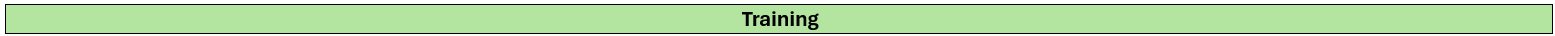
#Training Loop, Train_Model

In [ ]:
import numpy as np

def mixup_data(x, y, alpha=0.2):
    #Computes inputs, pairs of targets, and lambda for mixup
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                num_epochs,
                device):
    train_losses = []
    val_losses = []
    train_accuracies = []  # Added to track training accuracy
    val_accuracies = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Apply MixUp
            ##############
            inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha=0.05)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Compute mixed loss
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            #loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            # Track correct training predictions
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        train_accuracy = 100 * correct_train / total_train
        train_accuracies.append(train_accuracy)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)

        # Inside epoch loop, after calculating validation loss:
        scheduler.step()

        print(f"Epoch {epoch + 1}/{num_epochs} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")
        # Save best checkpoint

        if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          torch.save(model.state_dict(), 'best_model.pth')
          print(f"Epoch {epoch+1}: Saved Best Model (Val Loss: {avg_val_loss:.4f})")

    print('Finished Training')
    return train_losses, val_losses, train_accuracies, val_accuracies

#Train

In [ ]:
import time

num_epochs=15
start_time = time.time()

# 1. Run training and capture all four returned lists
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, device=device
)

end_time = time.time()
training_time = end_time - start_time
print(f"Model Training Time: {training_time:.2f} seconds")

Epoch 1/15 | Train Acc: 10.55% | Val Acc: 14.55%
Epoch 1: Saved Best Model (Val Loss: 2.3940)
Epoch 2/15 | Train Acc: 14.18% | Val Acc: 11.87%
Epoch 2: Saved Best Model (Val Loss: 2.3836)
Epoch 3/15 | Train Acc: 16.91% | Val Acc: 13.24%
Epoch 3: Saved Best Model (Val Loss: 2.3701)
Epoch 4/15 | Train Acc: 14.00% | Val Acc: 13.35%
Epoch 4: Saved Best Model (Val Loss: 2.3565)
Epoch 5/15 | Train Acc: 16.73% | Val Acc: 14.46%
Epoch 5: Saved Best Model (Val Loss: 2.3446)
Epoch 6/15 | Train Acc: 9.64% | Val Acc: 16.38%
Epoch 6: Saved Best Model (Val Loss: 2.3269)
Epoch 7/15 | Train Acc: 9.45% | Val Acc: 17.52%
Epoch 7: Saved Best Model (Val Loss: 2.3117)
Epoch 8/15 | Train Acc: 16.00% | Val Acc: 18.13%
Epoch 8: Saved Best Model (Val Loss: 2.2942)
Epoch 9/15 | Train Acc: 22.00% | Val Acc: 18.78%
Epoch 9: Saved Best Model (Val Loss: 2.2807)
Epoch 10/15 | Train Acc: 21.27% | Val Acc: 19.13%
Epoch 10: Saved Best Model (Val Loss: 2.2725)
Epoch 11/15 | Train Acc: 15.45% | Val Acc: 16.76%
Epoch 11: 

In [ ]:
#Final

import time

num_epochs=40
start_time = time.time()

# 1. Run training and capture all four returned lists
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, device=device
)

end_time = time.time()
training_time = end_time - start_time
print(f"Model Training Time: {training_time:.2f} seconds")

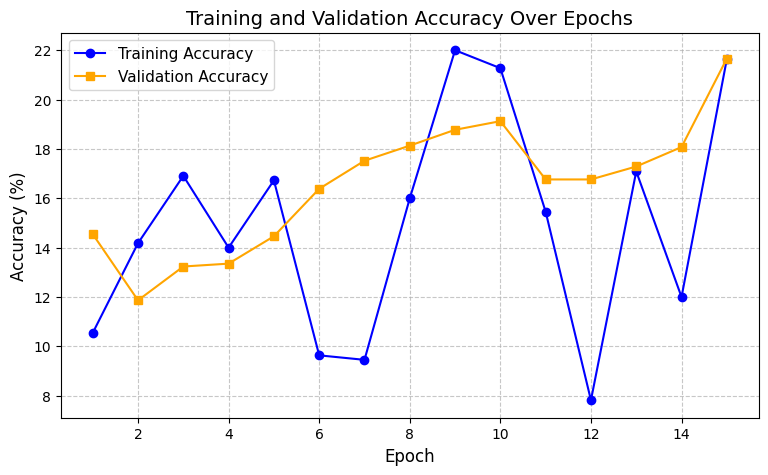

In [ ]:
import matplotlib.pyplot as plt

# 2. Plot Training vs. Validation Accuracy
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', marker='s', color='orange')

plt.title('Training and Validation Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

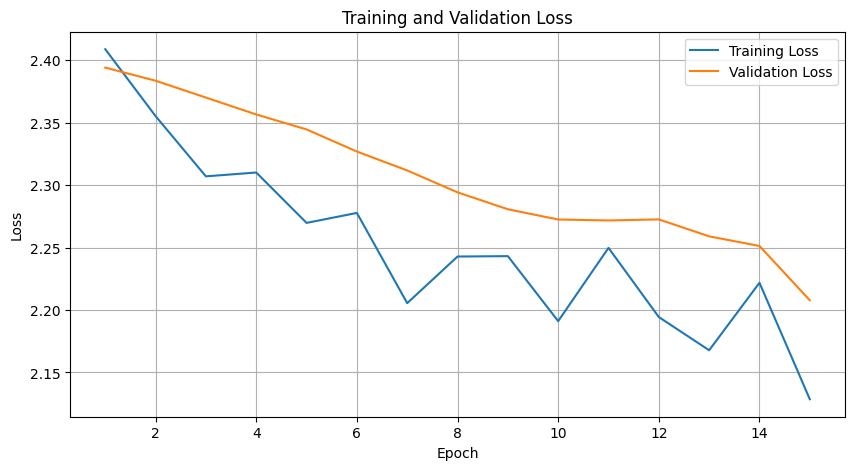

In [ ]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#Evaluation Using Test Data

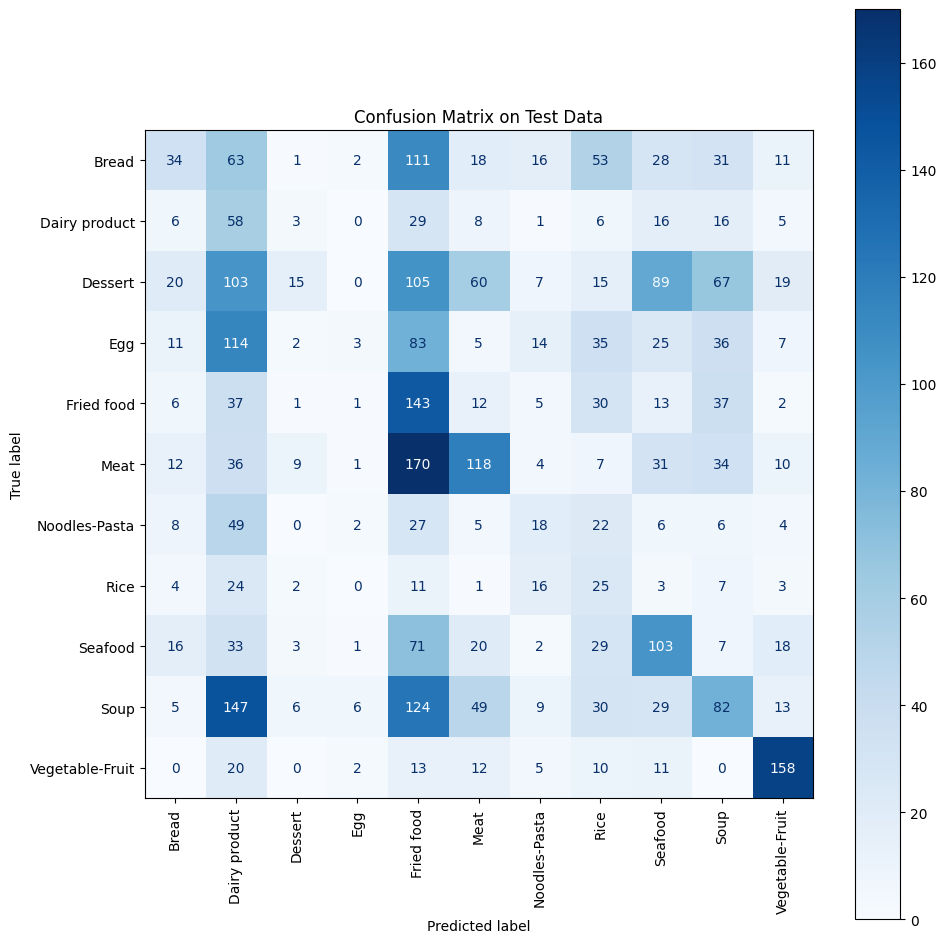

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

# Ensure model is in evaluation mode
model.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.classes)
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix on Test Data")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

 Overall Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"Overall Test Accuracy: {acc * 100:.2f}%\n")

# Detailed Classification Report (Precision, Recall, F1 for each class)
print("Classification Report:")
report = classification_report(all_labels, all_preds, target_names=test_data.classes)
print(report)

Overall Test Accuracy: 22.08%

Classification Report:
                 precision    recall  f1-score   support

          Bread       0.14      0.02      0.03       368
  Dairy product       0.14      0.25      0.18       148
        Dessert       0.33      0.00      0.01       500
            Egg       0.17      0.52      0.26       335
     Fried food       0.15      0.06      0.09       287
           Meat       0.53      0.22      0.31       432
  Noodles-Pasta       0.10      0.22      0.14       147
           Rice       0.08      0.45      0.14        96
        Seafood       0.36      0.18      0.24       303
           Soup       0.28      0.20      0.24       500
Vegetable-Fruit       0.50      0.76      0.61       231

       accuracy                           0.22      3347
      macro avg       0.25      0.26      0.20      3347
   weighted avg       0.29      0.22      0.19      3347



Option 1: Benchmark using the OpenAI API (ChatGPT / GPT-4o)
If you want to test against the exact intelligence of ChatGPT, you can write a short evaluation loop that sends test images directly to OpenAI's API.

Install the OpenAI library:

In [ ]:
!pip install openai

Option 2: Download a Free Local Vision Model (Ollama)
If you prefer a completely free, offline alternative that mimics a large multimodal chat model locally on your machine (or a cloud GPU), you can use Ollama to run models like Llama 3.2 Vision or Moondream.

Download and run Ollama (if running locally) or connect to it.

Pull a lightweight vision model like llava or llama3.2-vision:

saving the model

In [ ]:
import torch
import os

# Define a path to save model
model_save_path = "food11_simple_cnn.pth"

# Save the model state dictionary
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved successfully to {model_save_path}")

Model weights saved successfully to food11_simple_cnn0807C.pth


In [ ]:
# Initialize a fresh model architecture
loaded_model = SimpleCNN(num_classes=num_classes, p=0.5)

# Load the saved state dictionary into it
loaded_model.load_state_dict(torch.load(model_save_path))

# Move it to device and set to evaluation mode
loaded_model.to(device)
loaded_model.eval()


In [ ]:
torch.save(model, "food11_entire_model.pth")

In [ ]:
from google.colab import files

# Trigger the download prompt in browser
files.download("food11_simple_cnn.pth")